**Name:** Arun Bhaskar Gadde

**Course:** 2026 Summer - Advanced Big Data and Data Mining (MSCS-634-B01) - Second Bi-term

**Assignment:** Lab 4 - Regression Analysis with Regularization Techniques



## Step 1: Data Preparation

We use the **Diabetes dataset** built into `sklearn.datasets`. It contains 442 patient
records with 10 baseline physiological features (age, sex, BMI, blood pressure, and six
blood serum measurements) and a target that represents a quantitative measure of disease
progression one year after baseline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Load dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame
X_all = diabetes.data
y_all = diabetes.target

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [2]:
# Feature and target overview
print("Feature names:", diabetes.feature_names)
print()
print(df.describe().T)

Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

        count          mean        std        min        25%         50%  \
age     442.0 -2.511817e-19   0.047619  -0.107226  -0.037299    0.005383   
sex     442.0  1.230790e-17   0.047619  -0.044642  -0.044642   -0.044642   
bmi     442.0 -2.245564e-16   0.047619  -0.090275  -0.034229   -0.007284   
bp      442.0 -4.797570e-17   0.047619  -0.112399  -0.036656   -0.005670   
s1      442.0 -1.381499e-17   0.047619  -0.126781  -0.034248   -0.004321   
s2      442.0  3.918434e-17   0.047619  -0.115613  -0.030358   -0.003819   
s3      442.0 -5.777179e-18   0.047619  -0.102307  -0.035117   -0.006584   
s4      442.0 -9.042540e-18   0.047619  -0.076395  -0.039493   -0.002592   
s5      442.0  9.268604e-17   0.047619  -0.126097  -0.033246   -0.001947   
s6      442.0  1.130318e-17   0.047619  -0.137767  -0.033179   -0.001078   
target  442.0  1.521335e+02  77.093005  25.000000  87.000000  140.500000   

       

In [3]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


The scikit-learn Diabetes dataset ships pre-cleaned: all 10 feature columns have
already been mean-centered and scaled by the standard deviation, multiplied by the number
of samples, so there are **no missing values** and no additional cleaning is required.
We simply confirm this above. The target (`disease progression`) is a continuous value
ranging roughly from 25 to 346.

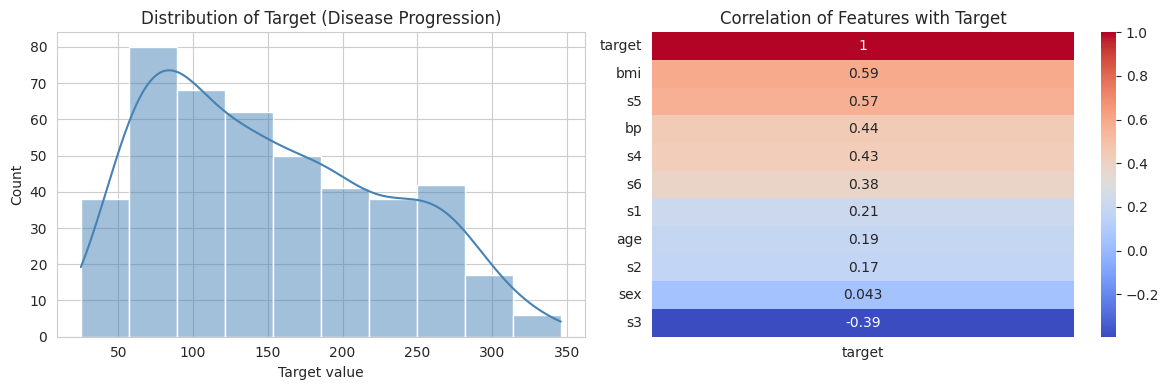

In [4]:
# Distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y_all, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Target (Disease Progression)")
axes[0].set_xlabel("Target value")

corr = df.corr()
sns.heatmap(corr[["target"]].sort_values("target", ascending=False), annot=True,
            cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlation of Features with Target")
plt.tight_layout()
plt.show()

**Observation:** `bmi` and `s5` show the strongest positive correlation with the
target, followed by `bp` (blood pressure) and `s4`. This suggests BMI is a strong
candidate for a simple linear regression model.

## Step 2: Simple Linear Regression

We use **BMI** (the feature most correlated with the target) as the single independent
variable to predict disease progression.

In [5]:
# Use BMI as the single feature
X_simple = X_all[["bmi"]]
y = y_all

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

lin_reg = LinearRegression()
lin_reg.fit(X_train_s, y_train_s)
y_pred_s = lin_reg.predict(X_test_s)

def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MAE:  {mae:.3f}")
    print(f"MSE:  {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R2:   {r2:.3f}\n")
    return {"Model": label, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

results = []
results.append(evaluate(y_test_s, y_pred_s, "Simple Linear Regression (BMI only)"))

--- Simple Linear Regression (BMI only) ---
MAE:  52.260
MSE:  4061.826
RMSE: 63.732
R2:   0.233



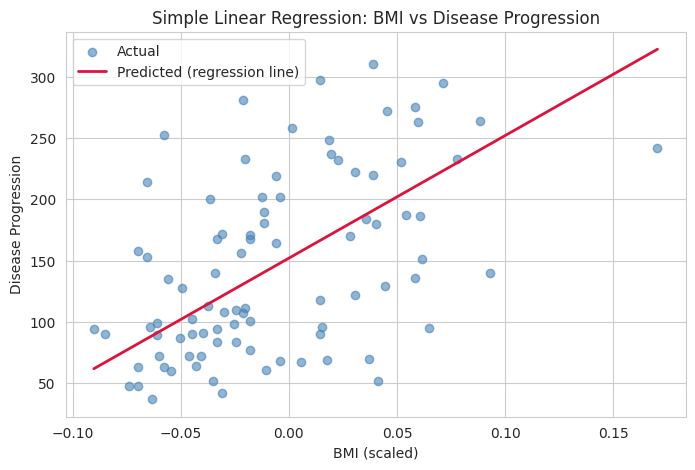

In [6]:
# Visualize predictions vs actual for simple linear regression
plt.figure()
plt.scatter(X_test_s, y_test_s, color="steelblue", alpha=0.6, label="Actual")
order = np.argsort(X_test_s["bmi"].values)
plt.plot(X_test_s["bmi"].values[order], y_pred_s[order], color="crimson", linewidth=2,
         label="Predicted (regression line)")
plt.xlabel("BMI (scaled)")
plt.ylabel("Disease Progression")
plt.title("Simple Linear Regression: BMI vs Disease Progression")
plt.legend()
plt.show()

**Observation:** A single feature (BMI) captures a moderate linear trend, but the
scatter of points around the line shows a lot of unexplained variance, which we'd expect
since disease progression depends on many physiological factors, not just BMI.

## Step 3: Multiple Regression

Now we use **all 10 features** to predict disease progression.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

mult_reg = LinearRegression()
mult_reg.fit(X_train, y_train)
y_pred_mult = mult_reg.predict(X_test)

results.append(evaluate(y_test, y_pred_mult, "Multiple Linear Regression (all features)"))

# Coefficients
coef_df = pd.DataFrame({"Feature": X_all.columns, "Coefficient": mult_reg.coef_})
coef_df.sort_values("Coefficient", key=abs, ascending=False)

--- Multiple Linear Regression (all features) ---
MAE:  42.794
MSE:  2900.194
RMSE: 53.853
R2:   0.453



,Feature,Coefficient
4,s1,-931.488846
8,s5,736.198859
2,bmi,542.428759
5,s2,518.062277
3,bp,347.703844
7,s4,275.317902
1,sex,-241.964362
6,s3,163.419983
9,s6,48.670657
0,age,37.904021


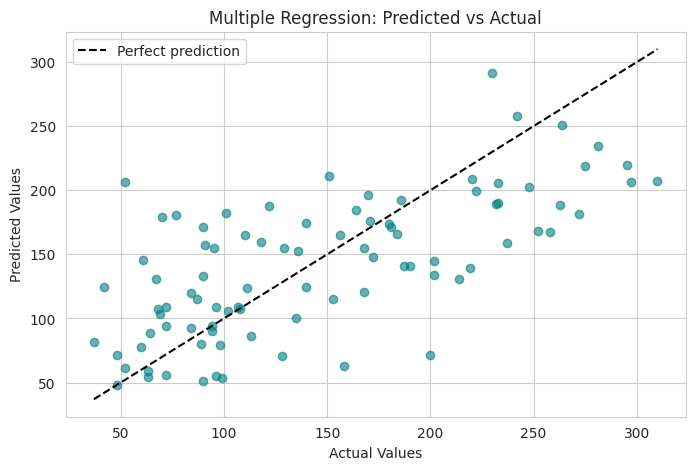

In [8]:
# Predicted vs actual
plt.figure()
plt.scatter(y_test, y_pred_mult, color="teal", alpha=0.6)
lims = [min(y_test.min(), y_pred_mult.min()), max(y_test.max(), y_pred_mult.max())]
plt.plot(lims, lims, color="black", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Multiple Regression: Predicted vs Actual")
plt.legend()
plt.show()

**Observation:** Using all 10 features noticeably improves R² compared to the
single-feature model, confirming that disease progression is driven by a combination of
BMI, blood pressure, and several serum measurements rather than any single variable.

## Step 4: Polynomial Regression

We extend the linear model with polynomial features (degree 2 and degree 3) generated
from all 10 base features, to see whether capturing non-linear interactions improves
performance — and at what point it starts to overfit.

In [9]:
def run_polynomial(degree, X_train, X_test, y_train, y_test, label):
    poly_model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        LinearRegression()
    )
    poly_model.fit(X_train, y_train)

    y_train_pred = poly_model.predict(X_train)
    y_test_pred = poly_model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"--- {label} ---")
    print(f"Train R2: {train_r2:.3f}   Test R2: {test_r2:.3f}")

    metrics = evaluate(y_test, y_test_pred, label)
    metrics["Train_R2"] = train_r2
    return metrics, poly_model

poly2_metrics, poly2_model = run_polynomial(2, X_train, X_test, y_train, y_test,
                                             "Polynomial Regression (degree 2)")
poly3_metrics, poly3_model = run_polynomial(3, X_train, X_test, y_train, y_test,
                                             "Polynomial Regression (degree 3)")

results.append(poly2_metrics)
results.append(poly3_metrics)

--- Polynomial Regression (degree 2) ---
Train R2: 0.606   Test R2: 0.416
--- Polynomial Regression (degree 2) ---
MAE:  43.582
MSE:  3096.028
RMSE: 55.642
R2:   0.416

--- Polynomial Regression (degree 3) ---
Train R2: 0.877   Test R2: -14.561
--- Polynomial Regression (degree 3) ---
MAE:  164.854
MSE:  82446.049
RMSE: 287.134
R2:   -14.561



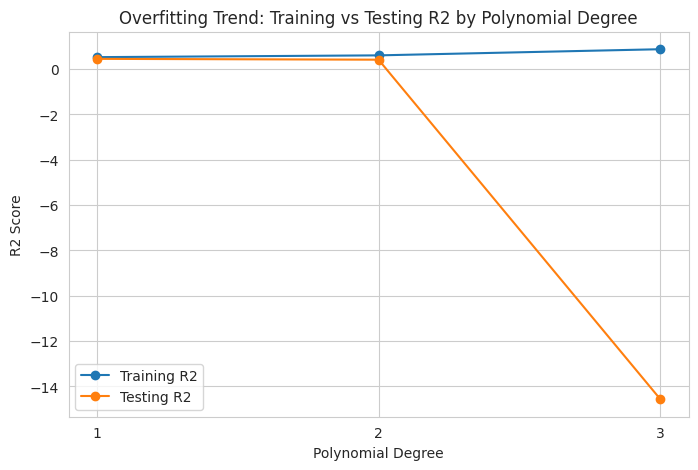

In [10]:
# Visualize train vs test R2 across degrees to show overfitting trend
degrees = [1, 2, 3]
train_scores = []
test_scores = []

for d in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=d, include_bias=False),
        StandardScaler(),
        LinearRegression()
    )
    model.fit(X_train, y_train)
    train_scores.append(r2_score(y_train, model.predict(X_train)))
    test_scores.append(r2_score(y_test, model.predict(X_test)))

plt.figure()
plt.plot(degrees, train_scores, marker="o", label="Training R2")
plt.plot(degrees, test_scores, marker="o", label="Testing R2")
plt.xlabel("Polynomial Degree")
plt.ylabel("R2 Score")
plt.title("Overfitting Trend: Training vs Testing R2 by Polynomial Degree")
plt.xticks(degrees)
plt.legend()
plt.show()

**Observation:** As the polynomial degree increases, the **training R²** keeps
climbing (the model fits the training data almost perfectly at degree 3), but the
**testing R²** stagnates or drops. This growing gap between training and testing
performance is the classic signature of **overfitting** — the higher-degree model is
learning noise specific to the training set rather than a generalizable pattern.

## Step 5: Regularization with Ridge and Lasso Regression

To control the overfitting seen in the polynomial model, we apply **Ridge (L2)** and
**Lasso (L1)** regularization on top of the degree-2 polynomial feature set, and compare
several alpha (penalty strength) values.

In [11]:
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly2.fit_transform(X_train)
X_test_poly = poly2.transform(X_test)

scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

ridge_results = []
lasso_results = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_poly_scaled, y_train)
    r_pred = ridge.predict(X_test_poly_scaled)
    ridge_results.append({
        "alpha": a,
        "R2": r2_score(y_test, r_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, r_pred)),
        "nonzero_coefs": np.sum(ridge.coef_ != 0)
    })

    lasso = Lasso(alpha=a, max_iter=20000)
    lasso.fit(X_train_poly_scaled, y_train)
    l_pred = lasso.predict(X_test_poly_scaled)
    lasso_results.append({
        "alpha": a,
        "R2": r2_score(y_test, l_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, l_pred)),
        "nonzero_coefs": np.sum(lasso.coef_ != 0)
    })

ridge_df = pd.DataFrame(ridge_results)
lasso_df = pd.DataFrame(lasso_results)

print("Ridge Regression across alpha values:")
display(ridge_df)
print("\nLasso Regression across alpha values:")
display(lasso_df)

Ridge Regression across alpha values:


,alpha,R2,RMSE,nonzero_coefs
0,0.01,0.416349,55.608200,65
1,0.10,0.421135,55.379712,65
2,1.00,0.455779,53.696955,65
3,10.00,0.503014,51.313828,65
4,100.00,0.498106,51.566582,65



Lasso Regression across alpha values:


,alpha,R2,RMSE,nonzero_coefs
0,0.01,0.421793,55.348259,62
1,0.10,0.478802,52.548887,54
2,1.00,0.516080,50.634784,36
3,10.00,0.446253,54.164885,4
4,100.00,-0.011963,73.222493,0


**How alpha influences the models:**
- **Ridge (L2):** shrinks all coefficients toward zero but rarely to exactly zero. Small
  alpha behaves like ordinary linear regression (can overfit); large alpha shrinks
  coefficients heavily and can underfit.
- **Lasso (L1):** can shrink some coefficients to exactly **zero**, effectively performing
  feature selection. As alpha grows, more coefficients get zeroed out — the model becomes
  simpler and less prone to overfitting, but too large an alpha causes underfitting
  (`nonzero_coefs` in the table above shows this shrinkage in action).

In [12]:
# Pick best-performing alpha (highest test R2) for each, then compare with earlier models
best_ridge_alpha = ridge_df.loc[ridge_df["R2"].idxmax(), "alpha"]
best_lasso_alpha = lasso_df.loc[lasso_df["R2"].idxmax(), "alpha"]

ridge_final = Ridge(alpha=best_ridge_alpha)
ridge_final.fit(X_train_poly_scaled, y_train)
y_pred_ridge = ridge_final.predict(X_test_poly_scaled)
results.append(evaluate(y_test, y_pred_ridge, f"Ridge Regression (alpha={best_ridge_alpha})"))

lasso_final = Lasso(alpha=best_lasso_alpha, max_iter=20000)
lasso_final.fit(X_train_poly_scaled, y_train)
y_pred_lasso = lasso_final.predict(X_test_poly_scaled)
results.append(evaluate(y_test, y_pred_lasso, f"Lasso Regression (alpha={best_lasso_alpha})"))

print(f"Best Ridge alpha: {best_ridge_alpha}, Best Lasso alpha: {best_lasso_alpha}")

--- Ridge Regression (alpha=10.0) ---
MAE:  39.867
MSE:  2633.109
RMSE: 51.314
R2:   0.503

--- Lasso Regression (alpha=1.0) ---
MAE:  40.038
MSE:  2563.881
RMSE: 50.635
R2:   0.516

Best Ridge alpha: 10.0, Best Lasso alpha: 1.0


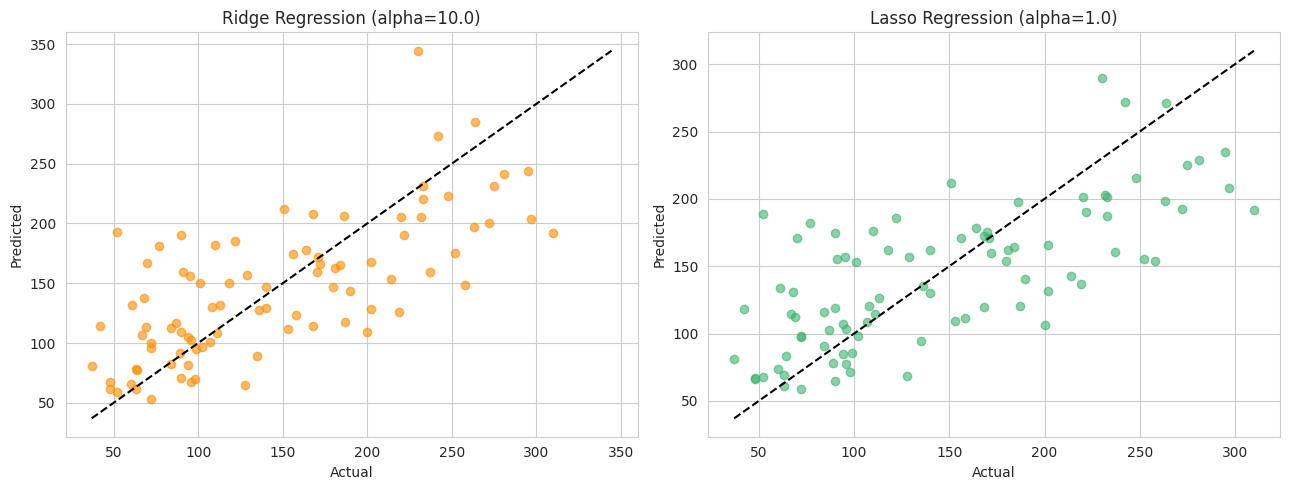

In [13]:
# Visualize Ridge vs Lasso predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_ridge, color="darkorange", alpha=0.6)
lims = [min(y_test.min(), y_pred_ridge.min()), max(y_test.max(), y_pred_ridge.max())]
axes[0].plot(lims, lims, color="black", linestyle="--")
axes[0].set_title(f"Ridge Regression (alpha={best_ridge_alpha})")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

axes[1].scatter(y_test, y_pred_lasso, color="mediumseagreen", alpha=0.6)
lims2 = [min(y_test.min(), y_pred_lasso.min()), max(y_test.max(), y_pred_lasso.max())]
axes[1].plot(lims2, lims2, color="black", linestyle="--")
axes[1].set_title(f"Lasso Regression (alpha={best_lasso_alpha})")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

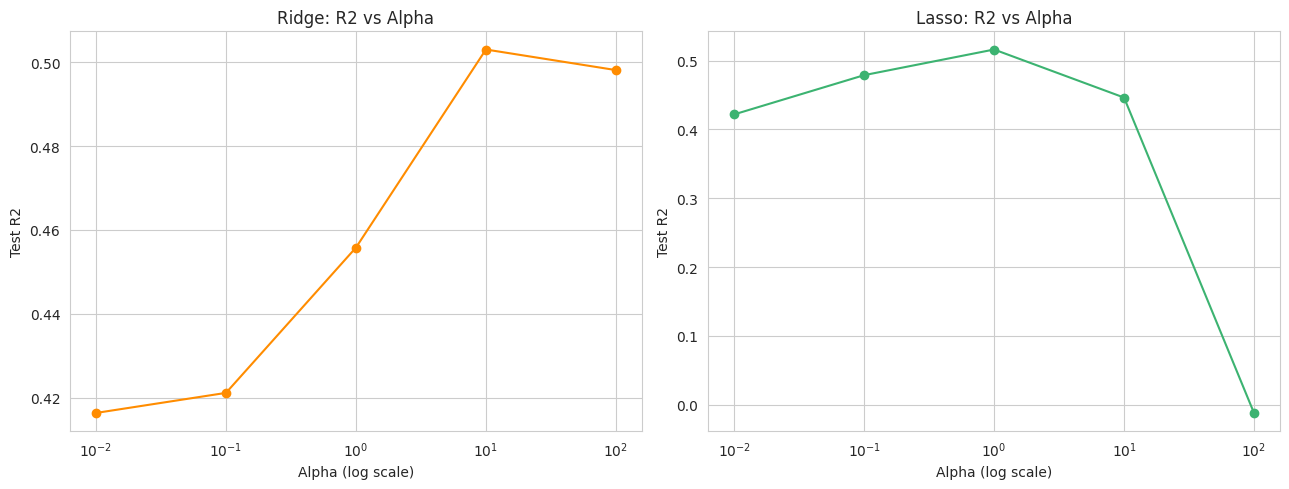

In [14]:
# R2 vs alpha curves - visualize regularization effect
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(ridge_df["alpha"], ridge_df["R2"], marker="o", color="darkorange")
axes[0].set_xscale("log")
axes[0].set_xlabel("Alpha (log scale)")
axes[0].set_ylabel("Test R2")
axes[0].set_title("Ridge: R2 vs Alpha")

axes[1].plot(lasso_df["alpha"], lasso_df["R2"], marker="o", color="mediumseagreen")
axes[1].set_xscale("log")
axes[1].set_xlabel("Alpha (log scale)")
axes[1].set_ylabel("Test R2")
axes[1].set_title("Lasso: R2 vs Alpha")

plt.tight_layout()
plt.show()

**Observation:** Both Ridge and Lasso improve upon the raw degree-2 polynomial
model's test performance for a well-chosen alpha, confirming that regularization reduces
overfitting on the polynomial feature set. Lasso additionally drives several coefficients
to zero, offering a simpler, more interpretable model, while Ridge keeps all features but
shrinks their influence.

## Step 6: Model Comparison and Analysis

In [15]:
summary_df = pd.DataFrame(results)[["Model", "MAE", "MSE", "RMSE", "R2"]]
summary_df = summary_df.sort_values("R2", ascending=False).reset_index(drop=True)
summary_df

,Model,MAE,MSE,RMSE,R2
0,Lasso Regression (alpha=1.0),40.037870,2563.881379,50.634784,0.516080
1,Ridge Regression (alpha=10.0),39.867079,2633.108968,51.313828,0.503014
2,Multiple Linear Regression (all features),42.794095,2900.193628,53.853446,0.452603
3,Polynomial Regression (degree 2),43.581693,3096.028307,55.641965,0.415640
4,Simple Linear Regression (BMI only),52.259976,4061.825928,63.732456,0.233350
5,Polynomial Regression (degree 3),164.853897,82446.048754,287.134200,-14.561285


/tmp/ipykernel_585/3520033563.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="R2", y="Model", palette="viridis")


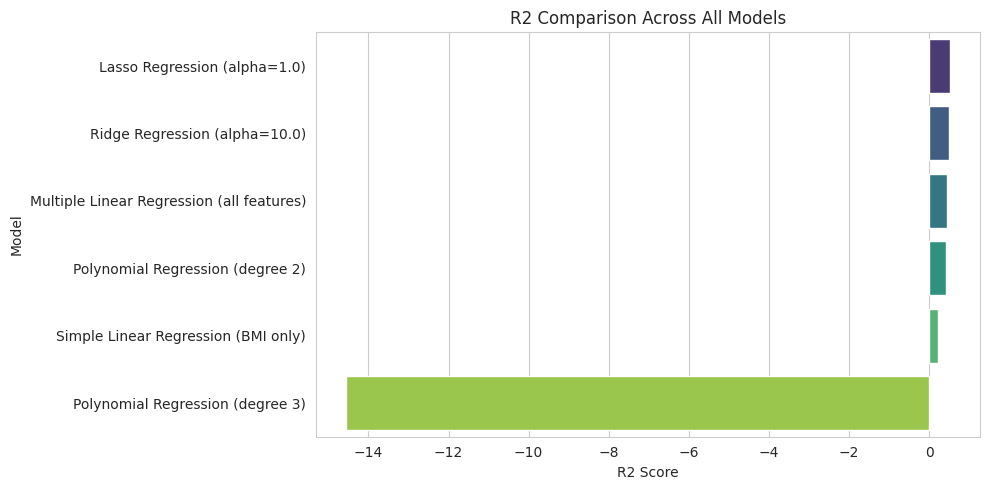

In [16]:
plt.figure(figsize=(10, 5))
sns.barplot(data=summary_df, x="R2", y="Model", palette="viridis")
plt.title("R2 Comparison Across All Models")
plt.xlabel("R2 Score")
plt.tight_layout()
plt.show()

### Summary and Discussion

**How well each model performed:**
- The **simple linear regression** (BMI only) had the weakest performance, since a
  single feature can't capture the multi-factor nature of disease progression.
- The **multiple linear regression** (all 10 features) improved R² substantially over the
  simple model, showing the value of using all available predictors.
- The **polynomial regression** models fit the training data increasingly well as degree
  increased, but test performance did not improve proportionally — degree 3 in particular
  showed a widening gap between training and test R², a clear sign of overfitting.
- **Ridge and Lasso regression**, applied to the polynomial feature set, recovered much of
  the lost generalization performance by penalizing large/unnecessary coefficients.

**Which models handled overfitting or improved performance:**
- Ridge and Lasso were the most effective at controlling overfitting introduced by the
  polynomial expansion. Ridge kept all features but shrank their weights, while Lasso
  performed implicit feature selection by zeroing out less useful coefficients.
- The alpha value was the key lever: too small behaved like plain linear/polynomial
  regression (risk of overfitting), while too large caused underfitting by shrinking
  coefficients too aggressively.

**Insights gained about the Diabetes dataset:**
- BMI, blood pressure, and the `s5` serum measurement are the strongest individual
  predictors of disease progression.
- The relationships in this dataset are largely linear-to-mildly-nonlinear; aggressive
  polynomial expansion (degree 3) adds complexity without proportional predictive benefit.
- Regularization is especially useful once the feature space grows (as happens with
  polynomial expansion), helping the model generalize rather than memorize the training
  set.